### Manual 4 ###

We can trade 4 different options:
- Vanilla call/put
- Chooser (choose call or put when TTE=1 week)
- Binary Put Option (all or nothing)
- Knock-out Put Option (if price > barrier it becomes worthless)

Our PnL will be simulated against the underlying 100 times and we get the average. The underlying has no meaninful price and is simply modelled via GBM so our price can be modeled BSM style:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

However then they go on to mention zero-risk neutral drift and a fixed vol of 251%. Thus after some algebra we can model price as:

$$S_t = S_0\exp{\sigma W_t - \frac{1}{2}\sigma^2t}$$ 

Interest rates are irrelevant for prosperity so no rho involved. But we have one more key piece of info: Prices evolve on a discrete grid of 4 steps per trading day, assuming 252 trading days per year. This is CRITICAL for the Knock-Out option, reason being that Prosperity only records the price 4 times a dess so the price is a lot less likely via just BM to breach the barrier. To model here correctly, we thus need to be careful to use the Broadie-Glasserman-Kou (1997) relationship since price is not recorded in continuous time. 

So to sum some stats:

- Contract Size: 3000
- Days Year (252)
- 4 steps per trading day
- No drift only GBM

**Volatility**
2-week vol: = $2.51 \cdot \sqrt{\frac{10}{252}} = 0.500$
3-week vol: = $2.51 \cdot \sqrt{\frac{15}{252}} = 0.612$

So standard deviations 0.500 and 0.612 which is massive. A one sigma move on 3-week vol is approx 1.53 price multiplier or +53%!

### So, trading ideas? ###

We don't know anything about the options prices in between and we cannot do anything in between the purchase and expiry so what we are supposed to do is likely observe the current prices. Then using our expression for the underlying apply BM to see if any of the options are undervalued and then assemble a hedged portfolio. 

However do we need to even strictly use BM here? That will work for vanilla options especially good since we are given a constant vol and the price simulation is literally just GBM. However a could more general "solution" be to model the probability distribution of the price paths and then instead of using BM as a "Black Box" directly observe the probability dist. to model with options are likely to be worth something vs useless at expiry?

Since we cannot rebalance or trade the options or anything else the factors and risks that affects the options during the time they are held become less relevant? The true question becomes what is the probability that the underlying ends ITM (and how much) for this option? This approach also makes the different exotics a lot easier to manage modelling wise. 

My solid idea is specify the path distribution and then compare the expected payoff for each of the options under this distribution. 

**Path Model**
We want to be able to find the probability when $S_T > K$ or $S_T < K$. Using our path expression for $S_T$ this means that:

$$S_T > K -> \log{S_T} > \log{K} ->  S_0 + \sigma Z \sqrt{T} > \log{K}$$

Then isolate Z and:

$$Z > \frac{\log(K/S_0) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

Then compute the probability as normal $P(S_T > K) = P(Z > z^*) = 1 - P(Z < z^*) = P(Z < - z^*)$

Note that conventionally we don't use Z, we use -Z so that d2 becomes the probability of finishing ITM in a call:

$$d_2 = -Z = \frac{\log(S_0/K) - \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

So using d2 we can now get finishing ITM call and -d2 finishing ITM put. Compute d1 and we get:

- P(S|ITM) = $N(d1)$ and $d_1 = \frac{\log(S_0/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$
- P(ITM) = $N(d2)$ and $d_2 = \frac{\log(S_0/K) - \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$

Thus we arrive at Black Scholes:

- $Price = E[Payoff] = (P(S|ITM) - K) * P(ITM)$

**CALL**
$$C = S_0 N(d1) - Ke^{-rT} N(d2)$$

**PUT**
$$C = Ke^{-rT} N(-d2) - S_0 N(-d1)$$

**Binary**
This should be extremely straightforward, just calculate the probability of the option ending ITM and multiply by the payoff to get the expected payoff then compare the expected payoff to the price. 

$$E[S - K] = P(ITM) \cdot (S-K)$$

**Vanilla Call/Put**
Here it is harder because we also need the expected payoff given we are ITM. 

$$E[S-K] = P(ITM)  \cdot E[S-K | S>K]$$

Now $E[S-K | S>K] = E[S| S>K] - K$ so we need to compute $E[S | S>K]$ now this is simply what is the average price when we are ITM and that is found by taking every probability of a given path X that paths end price to get a probability weighted average:

$$\int_{K}^{\infty} (s-K) \cdot f_{S_T}(s) ds$$

**Chooser and Knock-out**
Just monte-carlo over an insane amount of runs, closed-form solutions for knockout and chooser exists but don't really match the spec of Prosperity options. 



In [5]:
##MC for last two
import numpy as np

n_sims = 1000000

S0, sigma = 50.0, 2.51
dt = 1/(4*252)
timesteps_2w = 10 * 4
timesteps_3w = 15 * 4

#Use antithetic for variance reduction
half = n_sims // 2
Z_half = np.random.standard_normal((half, timesteps_3w))
Z = np.concatenate([Z_half, -Z_half])

#Paths
log_inc = Z * np.sqrt(dt)*sigma -0.5*sigma**2*dt #log(S/S0)  = Z * \sqrt{t} * sigma - 0.5sigma^2*dt
log_path = np.cumsum(log_inc, axis=1)

#Real prices -> S0 * exp(log normals)
log_path = np.concatenate([np.zeros((n_sims, 1)),log_path], axis=1) 
S = S0 * np.exp(log_path) 

S_2w = S[:, timesteps_2w] #end rows 2w
S_3w = S[:, timesteps_3w]
S_min = np.min(S[:, 0:timesteps_3w], axis=1)

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import norm

S0 = 50
SIGMA = 2.51
T2W = 10 / 252
T3W = 15 / 252

BIN_STRIKE = 40
BIN_PAY = 10
KO_STRIKE = 45
KO_BARRIER = 35
CH_STRIKE = 50

def prob_above(K, T):
    d2 = (np.log(S0/K) - 0.5*SIGMA**2*T) / (SIGMA*np.sqrt(T))
    return norm.cdf(d2)

def prob_below(K, T):
    d2 = (np.log(S0/K) - 0.5*SIGMA**2*T) / (SIGMA*np.sqrt(T))
    return norm.cdf(-d2)

def bsm(K, T_days):
    T = T_days / 252
    sqrtT = SIGMA * np.sqrt(T)
    d2 = (np.log(S0/K) - 0.5*SIGMA**2*T) / sqrtT
    d1 = d2 + sqrtT
    return d2, d1

def vanilla_call(strike, tte_days, d1, d2):
    return S0*norm.cdf(d1) - strike*norm.cdf(d2)

def vanilla_put(strike, tte_days, d1, d2):
    return strike*norm.cdf(-d2) - S0*norm.cdf(-d1)

def binary_put_fv():
    return prob_below(BIN_STRIKE, T3W) * BIN_PAY

def binary_put_pitm():
    return prob_below(BIN_STRIKE, T3W)

def knock_out_fv():
    vanilla_payoff = np.maximum(KO_STRIKE - S_3w, 0)
    return np.mean(np.where(S_min < KO_BARRIER, 0, vanilla_payoff))

def knock_out_pitm():
    pays = (S_3w < KO_STRIKE) & (S_min >= KO_BARRIER)
    return pays.mean()

def chooser_fv():
    call_p = np.maximum(S_3w - CH_STRIKE, 0)
    put_p = np.maximum(CH_STRIKE - S_3w, 0)
    payoff = np.where(S_2w > CH_STRIKE, call_p, put_p)
    return payoff.mean()

def chooser_pitm():
    is_call = S_2w > CH_STRIKE
    pays = ((is_call) & (S_3w > CH_STRIKE)) | ((~is_call) & (S_3w < CH_STRIKE))
    return pays.mean()

exotic_options = {
    "50_CO_3W":   (50, 15, 22.20, 22.30),
    "40_BIP_3W":  (40, 15, 5.00, 5.10),
    "45_KOP_3W":  (45, 15, 0.15, 0.175),
}

standard_options = {
    "60_CALL_3W":  (60, 15, 8.80, 8.85),
    "50_CALL_3W":  (50, 15, 12.00, 12.05),
    "50_PUT_3W":   (50, 15, 12.00, 12.05),
    "45_PUT_3W":   (45, 15, 9.05, 9.10),
    "40_PUT_3W":   (40, 15, 6.50, 6.55),
    "35_PUT_3W":   (35, 15, 4.33, 4.35),
    "50_CALL_2W":  (50, 10, 9.70, 9.75),
    "50_PUT_2W":   (50, 10, 9.70, 9.75),
}

rows = []

def add_row(key, strike, tte, bid, ask, fv, pitm_pays):
    edge_buy = fv - ask
    edge_sell = bid - fv
    
    if edge_buy > edge_sell and edge_buy > 0:
        edge, side = edge_buy, "BUY"
        pitm_for_side = pitm_pays
    elif edge_sell > 0:
        edge, side = edge_sell, "SELL"
        pitm_for_side = 1 - pitm_pays
    else:
        edge, side = max(edge_buy, edge_sell), "—"
        pitm_for_side = pitm_pays if edge_buy >= edge_sell else 1 - pitm_pays
    
    rows.append({
        "Option": key, "Strike": strike, "TTE": tte,
        "Bid": bid, "Ask": ask, "FV": fv,
        "P(profit)": pitm_for_side,
        "Edge_buy": edge_buy, "Edge_sell": edge_sell,
        "Best_edge": edge, "Side": side
    })

for key, (strike, tte, bid, ask) in exotic_options.items():
    if "BIP" in key:
        fv = binary_put_fv()
        pitm = binary_put_pitm()
    elif "CO" in key:
        fv = chooser_fv()
        pitm = chooser_pitm()
    elif "KOP" in key:
        fv = knock_out_fv()
        pitm = knock_out_pitm()
    add_row(key, strike, tte, bid, ask, fv, pitm)

for key, (strike, tte, bid, ask) in standard_options.items():
    T = tte / 252
    d_2, d_1 = bsm(strike, tte)
    if "CALL" in key:
        fv = vanilla_call(strike, tte, d_1, d_2)
        pitm = prob_above(strike, T)
    elif "PUT" in key:
        fv = vanilla_put(strike, tte, d_1, d_2)
        pitm = prob_below(strike, T)
    add_row(key, strike, tte, bid, ask, fv, pitm)

df = pd.DataFrame(rows).sort_values("Best_edge", ascending=False).reset_index(drop=True)

df["$_edge"] = df["Best_edge"] * 3000
df["$_max_pos"] = df["$_edge"] * 50

df = df[["Option", "Strike", "TTE", "P(profit)", "FV", "Bid", "Ask",
         "Edge_buy", "Edge_sell", "Best_edge", "$_edge", "$_max_pos", "Side"]]

def color_side(val):
    if val == "BUY":
        return "background-color: #1a4d2e; color: white; font-weight: bold;"
    elif val == "SELL":
        return "background-color: #6b1d1d; color: white; font-weight: bold;"
    return "color: #888;"

def color_edge(val):
    if pd.isna(val):
        return ""
    if abs(val) < 0.025:
        return "color: #888;"
    elif val > 0:
        return f"background-color: rgba(40, 180, 80, {min(val/0.5, 1.0):.2f}); font-weight: bold;"
    else:
        return f"background-color: rgba(200, 60, 60, {min(abs(val)/0.5, 1.0):.2f});"

def color_pitm(val):
    return f"background-color: rgba(70, 130, 200, {val:.2f}); color: white;"

def color_dollar(val):
    if pd.isna(val) or abs(val) < 1000:
        return "color: #888;"
    elif val > 0:
        return f"background-color: rgba(40, 180, 80, {min(val/30000, 1.0):.2f}); font-weight: bold;"
    else:
        return f"background-color: rgba(200, 60, 60, {min(abs(val)/30000, 1.0):.2f});"

def highlight_best(row):
    styles = [""] * len(row)
    edge_buy_idx = list(row.index).index("Edge_buy")
    edge_sell_idx = list(row.index).index("Edge_sell")
    if row["Side"] == "BUY":
        styles[edge_buy_idx] = "border: 2px solid #4ade80;"
    elif row["Side"] == "SELL":
        styles[edge_sell_idx] = "border: 2px solid #f87171;"
    return styles

styled = (
    df.style
    .format({
        "Strike": "{:.0f}",
        "TTE": "{:.0f}d",
        "P(profit)": "{:.1%}",
        "FV": "{:.3f}",
        "Bid": "{:.3f}",
        "Ask": "{:.3f}",
        "Edge_buy": "{:+.3f}",
        "Edge_sell": "{:+.3f}",
        "Best_edge": "{:+.3f}",
        "$_edge": "${:+,.0f}",
        "$_max_pos": "${:+,.0f}",
    })
    .map(color_side, subset=["Side"])
    .map(color_edge, subset=["Edge_buy", "Edge_sell", "Best_edge"])
    .map(color_pitm, subset=["P(profit)"])
    .map(color_dollar, subset=["$_edge", "$_max_pos"])
    .apply(highlight_best, axis=1)
    .set_table_styles([
        {"selector": "thead th",
         "props": "background-color: #2d3748; color: white; font-weight: bold; "
                  "padding: 8px 12px; text-align: center; border-bottom: 2px solid #4a5568;"},
        {"selector": "tbody td",
         "props": "padding: 6px 12px; text-align: right; "
                  "font-family: 'SF Mono', Monaco, monospace; font-size: 13px;"},
        {"selector": "tbody td:nth-child(2)",
         "props": "text-align: left; font-weight: bold; color: #e2e8f0;"},
        {"selector": "thead th:first-child", "props": "display: none;"},
        {"selector": "tbody th", "props": "display: none;"},
        {"selector": "tbody tr:hover",
         "props": "background-color: rgba(255,255,255,0.05);"},
        {"selector": "tbody tr:nth-child(even)",
         "props": "background-color: rgba(255,255,255,0.02);"},
        {"selector": "",
         "props": "border-collapse: collapse; border: 1px solid #4a5568;"},
    ])
    .set_caption("Option pricing — sorted by best edge")
    .set_table_attributes('style="background: #1a202c; color: #e2e8f0;"')
)

styled

,Option,Strike,TTE,P(profit),FV,Bid,Ask,Edge_buy,Edge_sell,Best_edge,$_edge,$_max_pos,Side
0,50_CO_3W,50,15d,18.9%,21.872,22.200,22.300,-0.428,+0.328,+0.328,$+984,"$+49,217",SELL
1,40_BIP_3W,40,15d,52.3%,4.768,5.000,5.100,-0.332,+0.232,+0.232,$+696,"$+34,808",SELL
2,50_CALL_2W,50,10d,40.1%,9.871,9.700,9.750,+0.121,-0.171,+0.121,$+362,"$+18,106",BUY
3,50_PUT_2W,50,10d,59.9%,9.871,9.700,9.750,+0.121,-0.171,+0.121,$+362,"$+18,106",BUY
4,45_KOP_3W,45,15d,5.3%,0.253,0.150,0.175,+0.078,-0.103,+0.078,$+235,"$+11,765",BUY
5,60_CALL_3W,60,15d,72.7%,8.792,8.800,8.850,-0.058,+0.008,+0.008,$+25,"$+1,231",SELL
6,35_PUT_3W,35,15d,60.9%,4.336,4.330,4.350,-0.014,-0.006,-0.006,$-18,$-922,—
7,40_PUT_3W,40,15d,52.3%,6.510,6.500,6.550,-0.040,-0.010,-0.010,$-29,"$-1,431",—
8,45_PUT_3W,45,15d,55.3%,9.089,9.050,9.100,-0.011,-0.039,-0.011,$-33,"$-1,665",—
9,50_CALL_3W,50,15d,38.0%,12.027,12.000,12.050,-0.023,-0.027,-0.023,$-69,"$-3,458",—


Strategy                                            E[PnL]         σ/path    IMC-100 σ        p1 path    P(loss)
-------------------------------------------------------------------------------------------------------------------
Naked short chooser                                +49,217     +3,713,444     +371,521    -14,951,010      42.4%
Short chooser + (C_3W + P_2W)                      +58,948     +1,471,415     +147,106     -3,164,782      35.4%
Short chooser + (C_2W + P_3W)                      +61,237     +2,726,907     +273,063    -10,188,390      39.7%
Short chooser + avg replication (25/25)            +60,093     +1,549,281     +154,815     -5,064,195      34.0%
Long 2W straddle                                   +34,434     +2,678,523     +267,145     -2,876,574      47.0%


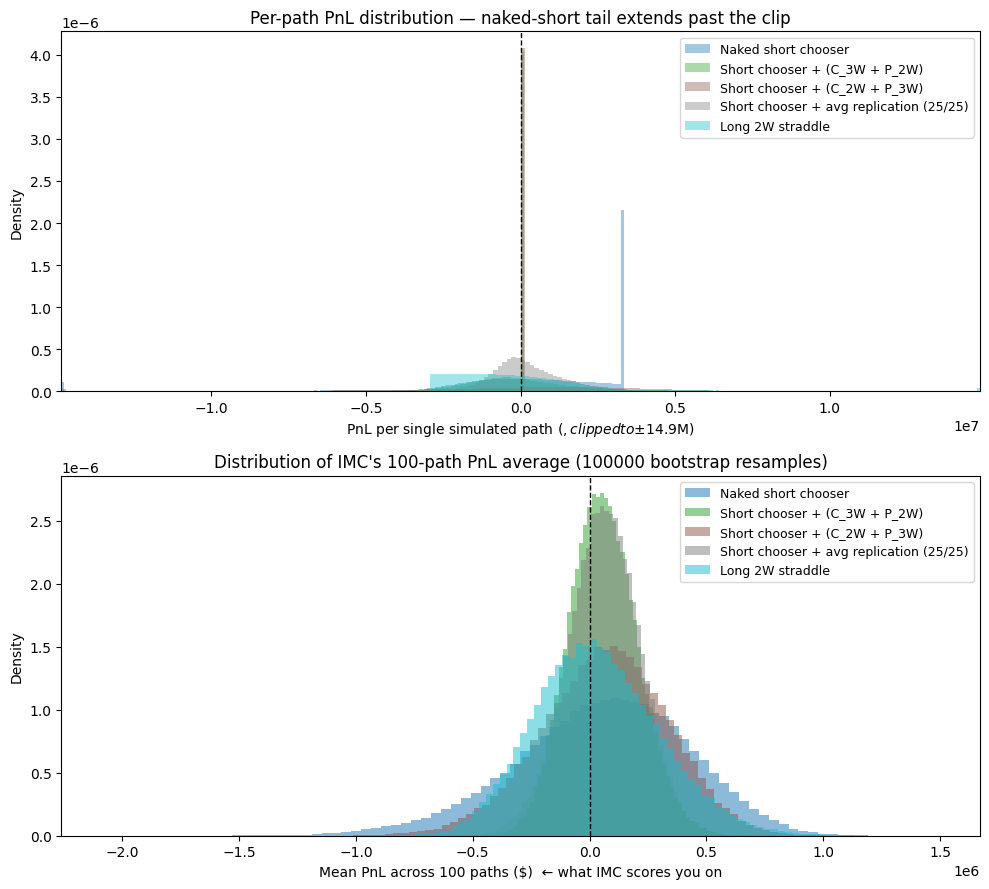


IMC 100-path PnL percentiles ($):
Strategy                                                5%          25%          50%          75%          95%
--------------------------------------------------------------------------------------------------------------
Naked short chooser                               -597,297     -184,722       71,519      310,457      619,610
Short chooser + (C_3W + P_2W)                     -175,565      -42,516       54,316      155,407      307,441
Short chooser + (C_2W + P_3W)                     -400,982     -116,101       69,813      248,238      492,249
Short chooser + avg replication (25/25)           -200,033      -41,148       62,334      164,775      308,999
Long 2W straddle                                  -383,821     -152,345       19,428      203,818      495,854


In [7]:
## MC the chooser-replication trade vs IMC's 100-path PnL sim

import numpy as np
import matplotlib.pyplot as plt

CONTRACT_SIZE = 3000
POS_LIMIT = 50

call_3w = np.maximum(S_3w - 50, 0)
put_3w  = np.maximum(50 - S_3w, 0)
call_2w = np.maximum(S_2w - 50, 0)
put_2w  = np.maximum(50 - S_2w, 0)

chooser_payoff = np.where(S_2w > 50, call_3w, put_3w)

P_CHOOSER_BID = 22.20
P_C3W_ASK     = 12.05
P_P2W_ASK     = 9.75
P_C2W_ASK     = 9.75
P_P3W_ASK     = 12.05

rep1_payoff = call_3w + put_2w - chooser_payoff
rep1_credit = P_CHOOSER_BID - P_C3W_ASK - P_P2W_ASK   # = 0.40

rep2_payoff = call_2w + put_3w - chooser_payoff
rep2_credit = P_CHOOSER_BID - P_C2W_ASK - P_P3W_ASK   # = 0.40

rep_avg_payoff = 0.5 * rep1_payoff + 0.5 * rep2_payoff
rep_avg_credit = 0.40

naked_payoff = -chooser_payoff
naked_credit = P_CHOOSER_BID

straddle_payoff = call_2w + put_2w
straddle_credit = -(P_C2W_ASK + P_P2W_ASK)

strategies = {
    "Naked short chooser":                     (naked_payoff,   naked_credit,   50),
    "Short chooser + (C_3W + P_2W)":           (rep1_payoff,    rep1_credit,    50),
    "Short chooser + (C_2W + P_3W)":           (rep2_payoff,    rep2_credit,    50),
    "Short chooser + avg replication (25/25)": (rep_avg_payoff, rep_avg_credit, 50),
    "Long 2W straddle":                        (straddle_payoff, straddle_credit, 50),
}

N_RESAMPLE = 100000
N_PATHS_IMC = 100

print(f"{'Strategy':<45} {'E[PnL]':>12} {'σ/path':>14} {'IMC-100 σ':>12} {'p1 path':>14} {'P(loss)':>10}")
print("-" * 115)

results = {}
for name, (payoff, credit, n_packs) in strategies.items():
    pnl_per_path = n_packs * CONTRACT_SIZE * (credit + payoff)
    mean_pnl   = pnl_per_path.mean()
    std_pnl    = pnl_per_path.std()
    p1_path    = np.percentile(pnl_per_path, 1)
    
    idx = np.random.randint(0, n_sims, size=(N_RESAMPLE, N_PATHS_IMC))
    imc_means = pnl_per_path[idx].mean(axis=1)
    imc_std   = imc_means.std()
    p_loss    = (imc_means < 0).mean()
    
    results[name] = (pnl_per_path, imc_means, mean_pnl, std_pnl, imc_std, p_loss)
    print(f"{name:<45} {mean_pnl:>+12,.0f} {std_pnl:>+14,.0f} {imc_std:>+12,.0f} {p1_path:>+14,.0f} {p_loss:>10.1%}")

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

colors = plt.cm.tab10(np.linspace(0, 1, len(strategies)))

# Per-path: scale x-axis to ~4σ of the widest strategy so the naked-short tail is visible
ax = axes[0]
xmax = max(results[n][3] for n in strategies) * 4
for (name, (pnl_per_path, _, _, _, _, _)), c in zip(results.items(), colors):
    clipped = np.clip(pnl_per_path, -xmax, xmax)
    ax.hist(clipped, bins=200, alpha=0.4, label=name, color=c, density=True)
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel(f"PnL per single simulated path ($, clipped to ±${xmax/1e6:.1f}M)")
ax.set_ylabel("Density")
ax.set_title("Per-path PnL distribution — naked-short tail extends past the clip")
ax.legend(fontsize=9)
ax.set_xlim(-xmax, xmax)

ax = axes[1]
for (name, (_, imc_means, _, _, _, _)), c in zip(results.items(), colors):
    ax.hist(imc_means, bins=80, alpha=0.5, label=name, color=c, density=True)
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("Mean PnL across 100 paths ($)  ← what IMC scores you on")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of IMC's 100-path PnL average ({N_RESAMPLE} bootstrap resamples)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nIMC 100-path PnL percentiles ($):")
print(f"{'Strategy':<45} {'5%':>12} {'25%':>12} {'50%':>12} {'75%':>12} {'95%':>12}")
print("-" * 110)
for name, (_, imc_means, _, _, _, _) in results.items():
    pcts = np.percentile(imc_means, [5, 25, 50, 75, 95])
    print(f"{name:<45} " + " ".join(f"{p:>12,.0f}" for p in pcts))

In [ ]:
combined_payoff = (
    50 * 3000 * (0.40 + (call_3w + put_2w - chooser_payoff))         # strategy 1
    + 50 * 3000 * (5.00 - 10 * (S_3w < 40))                          # binary short
    + 100 * 3000 * (-0.175 + np.where(S_min < 35, 0, np.maximum(45 - S_3w, 0)))  # KO long
)

idx = np.random.randint(0, n_sims, size=(N_RESAMPLE, N_PATHS_IMC))
imc_means = combined_payoff[idx].mean(axis=1)

print(f"Mean: {imc_means.mean():>+12,.0f}")
print(f"5%:   {np.percentile(imc_means, 5):>+12,.0f}")
print(f"25%:  {np.percentile(imc_means, 25):>+12,.0f}")
print(f"50%:  {np.percentile(imc_means, 50):>+12,.0f}")
print(f"75%:  {np.percentile(imc_means, 75):>+12,.0f}")
print(f"95%:  {np.percentile(imc_means, 95):>+12,.0f}")
print(f"P(>0): {(imc_means > 0).mean():.3f}")
print(f"P(>$200k): {(imc_means > 200_000).mean():.3f}")

Mean:     +118,003
5%:       -197,993
25%:       -14,394
50%:      +115,899
75%:      +247,784
95%:      +442,050
P(>0): 0.726
P(>$200k): 0.333
